#### EDA (Exploratory Dataset Analysis)

In [1]:
import pandas as pd

df = pd.read_csv('..\\data\\processed\\master_df.csv')
print(df.shape)

(7043, 50)


First question we'll answer: What does the overall churn rate look like?

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

churn_counts = df['Churn Label'].value_counts()
print(churn_counts)
print(f"\nChurn Rate: {churn_counts['Yes'] / len(df) * 100:.1f}%")

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

Churn Rate: 26.5%


26.5% churn rate. That's actually high for a telecom company — industry average is around 15-20%. This tells you the business has a real problem worth solving.

C:\Users\Mujtaba Jafri\AppData\Local\Temp\ipykernel_19092\4265526874.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn Label', palette='Set2')


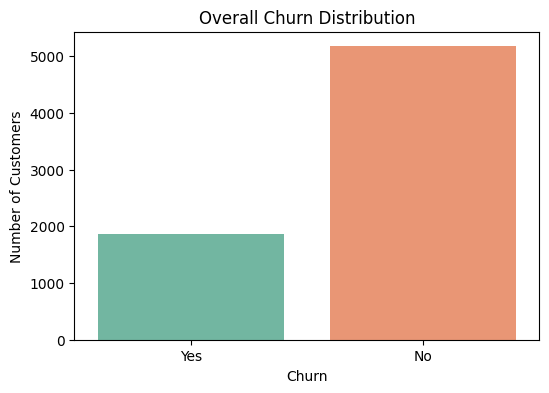

In [3]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Churn Label', palette='Set2')
plt.title('Overall Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.savefig('eda_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

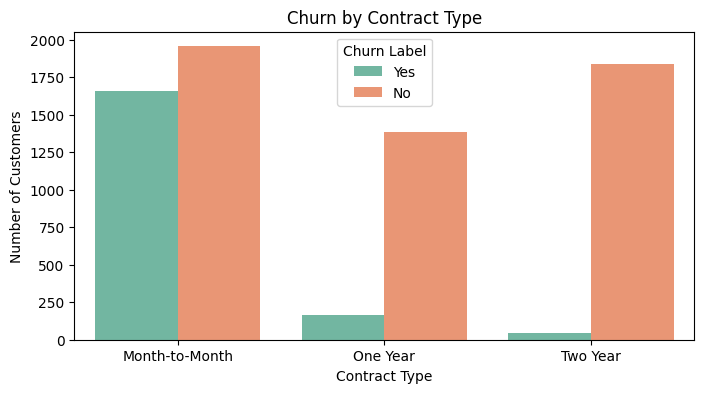

In [4]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='Contract', hue='Churn Label', palette='Set2')
plt.title('Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.savefig('eda_churn_by_contract.png', dpi=150, bbox_inches='tight')
plt.show()

That's a critical business insight. Customers on month-to-month contracts churn at a much higher rate because there's no lock-in — they can leave any time with no penalty.

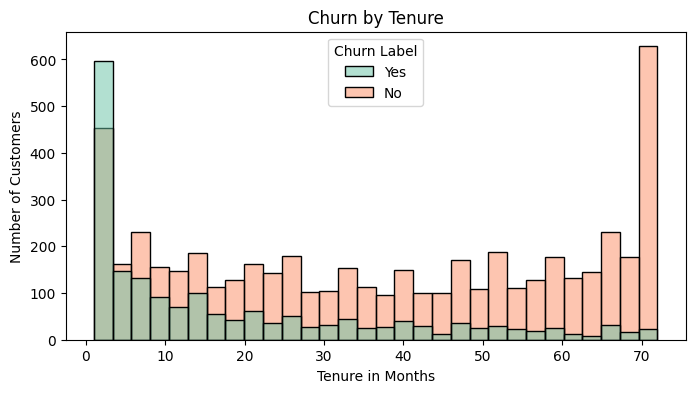

In [5]:
plt.figure(figsize=(8,4))
sns.histplot(data=df, x='Tenure in Months', hue='Churn Label', bins=30, palette='Set2')
plt.title('Churn by Tenure')
plt.xlabel('Tenure in Months')
plt.ylabel('Number of Customers')
plt.savefig('eda_churn_by_tenure.png', dpi=150, bbox_inches='tight')
plt.show()

 Two key insights here:

New customers (0-10 months) churn the most — they haven't built loyalty yet. This is called "early churn" and is very common in telecom.
Long tenure customers (60-70 months) almost never churn — they're loyal, committed customers.

Left peak = high risk, needs retention offers immediately
Right peak = loyal customers, don't waste retention budget on them

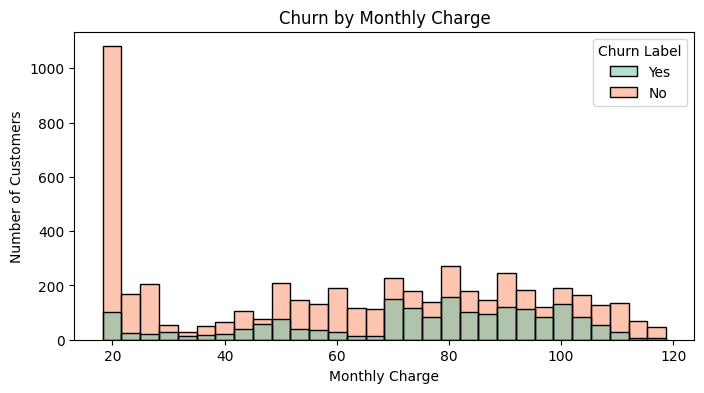

In [6]:
plt.figure(figsize=(8,4))
sns.histplot(data=df, x='Monthly Charge', hue='Churn Label', bins=30, palette='Set2')
plt.title('Churn by Monthly Charge')
plt.xlabel('Monthly Charge')
plt.ylabel('Number of Customers')
plt.savefig('eda_churn_by_monthly_charge.png', dpi=150, bbox_inches='tight')
plt.show()

The middle-to-high paying customers ($70-$105) churn the most. These are dangerous because they're paying enough to be valuable, but not so committed that they stay. The very highest payers ($120) actually churn less — possibly because they're on bundled contracts.

C:\Users\Mujtaba Jafri\AppData\Local\Temp\ipykernel_19092\2099127010.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_reasons.values, y=churn_reasons.index, palette='Set2')


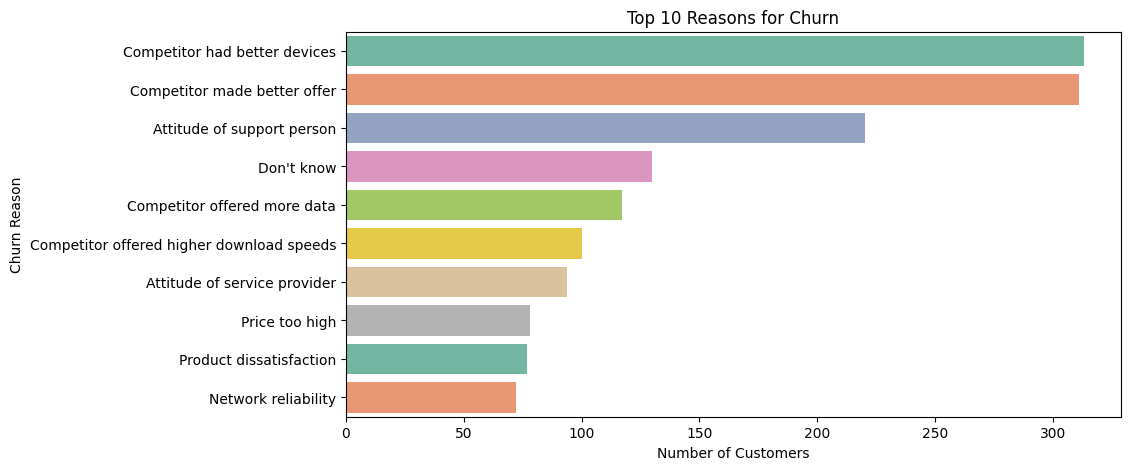

In [7]:
churn_reasons = df[df['Churn Label'] == 'Yes']['Churn Reason'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=churn_reasons.values, y=churn_reasons.index, palette='Set2')
plt.title('Top 10 Reasons for Churn')
plt.xlabel('Number of Customers')
plt.savefig('eda_top_churn_reasons.png', dpi=150, bbox_inches='tight')
plt.show()

The top reason is competitor — better devices and better offers account for ~600 customers leaving. That's not a product problem, that's a pricing and marketing problem. The business needs to monitor competitor offers and respond.
Second biggest is attitude of support staff at 240 — that's entirely fixable internally. Training and support quality improvement could recover those customers.